# README and documentation figures

This notebook draws the four figures the README and the docs site show, and
checks the code those pages print. Run it from `docs/figures/` after a change
that could move a figure or a printed number.

The figures are written to `docs/source/_static/`. The README reads them from
there by repository path, and the Sphinx build reads the same files through
`_static/`, so there is one copy of each.

The sample sweep in section 2 takes a long time and needs KSG from
`benchmark-mi`, so its result is cached in `sample_sweep.json` next to this
notebook. Delete that file to recompute it.


In [1]:
import json, pathlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import norm

import neural_mi as nmi

OUT = pathlib.Path('../source/_static')
OUT.mkdir(parents=True, exist_ok=True)
CACHE = pathlib.Path('.')        # sample_sweep.json lives next to this notebook
ROOT = pathlib.Path('../..')     # the repository, for the pages checked in sections 5 and 6

# ---- one place to restyle everything ---------------------------------------
BLUE, RED, GREEN, AMBER, GREY = '#1f6feb', '#c1440e', '#2da44e', '#b07d2b', '#8b949e'
DPI = 300

mpl.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

def save(fig, name):
    p = OUT / f'{name}.png'
    fig.savefig(p, dpi=DPI)
    print(f'wrote {p}')

## 1. What a correlation reports as zero

$Y = |X| + \sigma\varepsilon$. The relation is symmetric about zero, so the
upward and downward halves of any linear trend cancel exactly and the
correlation is zero by construction. The mutual information is large, and known
in closed form.


In [2]:
FOLD_N, FOLD_SIGMA, SEED = 4000, 0.2, 0

def fold_pair(n, dim=1, sigma=FOLD_SIGMA, seed=SEED):
    rng = np.random.default_rng(seed)
    x = rng.standard_normal((n, dim))
    return x, np.abs(x) + sigma * rng.standard_normal((n, dim))

def fold_exact_mi(sigma=FOLD_SIGMA, n_grid=200_001):
    s = np.sqrt(1 + sigma ** 2)
    y = np.linspace(-12 * s, 12 * s, n_grid)
    p = 2 * norm.pdf(y, 0, s) * norm.cdf(y / (sigma * s))
    h_y = -np.sum(p * np.log2(np.maximum(p, 1e-300))) * (y[1] - y[0])
    return float(h_y - 0.5 * np.log2(2 * np.pi * np.e * sigma ** 2))

x_fold, y_fold = fold_pair(FOLD_N)
FOLD_MI = fold_exact_mi()
FOLD_R = float(np.corrcoef(x_fold[:, 0], y_fold[:, 0])[0, 1])
print(f'exact MI = {FOLD_MI:.2f} bits    Pearson r = {FOLD_R:+.3f}')

exact MI = 1.55 bits    Pearson r = +0.001


wrote ../source/_static/correlation_blind.png


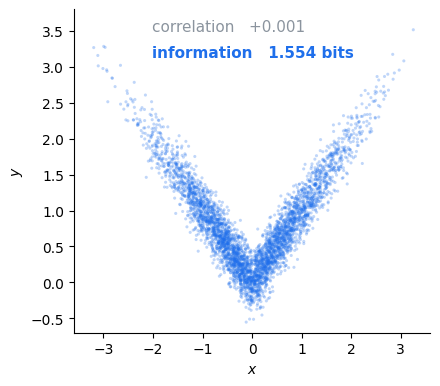

In [3]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(x_fold[:, 0], y_fold[:, 0], s=5, alpha=.28, color=BLUE,
           edgecolors='none', rasterized=True)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-0.7, 3.8)

ax.text(.22, .97, f'correlation   {FOLD_R:+.3f}', transform=ax.transAxes,
        va='top', fontsize=11, color=GREY)
ax.text(.22, .89, f'information   {FOLD_MI:.3f} bits', transform=ax.transAxes,
        va='top', fontsize=11, color=BLUE, fontweight='bold')

save(fig, 'correlation_blind')

## 2. Ten shared dimensions at every sample size

Ten latent dimensions carry 4 bits and reach each side through 1000 observed
channels. KSG and NeuralMI each estimate the information at every sample size,
over five seeds.


In [4]:
LATENT3, MI_TRUE3, DIM3 = 10, 4.0, 1000
N_LIST = [100, 300, 500, 700, 1000, 3000, 5000]
SEEDS3 = 5

cache3 = CACHE / 'sample_sweep.json'
if cache3.exists():
    nsweep = json.loads(cache3.read_text())
    print('loaded cached sweep; delete sample_sweep.json to recompute')
else:
    import bmi  # pip install benchmark-mi
    ksg_est3 = bmi.estimators.KSGEnsembleFirstEstimator(neighborhoods=(5, 10))
    nsweep = {'n_list': N_LIST, 'ksg': [], 'neural': [],
              'latent': LATENT3, 'mi_true': MI_TRUE3, 'dim': DIM3, 'seeds': SEEDS3}
    for N in N_LIST:
        k_runs, n_runs = [], []
        for s in range(SEEDS3):
            x, y = nmi.generators.generate_nonlinear_from_latent(
                n_samples=N, latent_dim=LATENT3, observed_dim=DIM3,
                mi=MI_TRUE3, seed=s)
            x, y = np.asarray(x), np.asarray(y)
            k_runs.append(float(ksg_est3.estimate(x, y) / np.log(2)))
            r = nmi.run(x, y, mode='estimate',
                        model=nmi.Model(hidden_dim=128, embedding_dim=32),
                        training=nmi.Training(n_epochs=150, patience=30,
                                              learning_rate=1e-3),
                        split=nmi.Split(mode='random'),
                        n_workers=1, seed=s, show_progress=False)
            n_runs.append(float(r.mi_estimate))
        nsweep['ksg'].append(k_runs)
        nsweep['neural'].append(n_runs)
        print(f'N={N:>5}  KSG {np.mean(k_runs):.2f}  NeuralMI {np.mean(n_runs):.2f}')
    cache3.write_text(json.dumps(nsweep, indent=1))

loaded cached sweep; delete sample_sweep.json to recompute


     N    KSG        NeuralMI
   100   0.77    2.64 +/- 1.44
   300   1.10    4.22 +/- 0.54
   500   1.24    4.54 +/- 0.25
   700   1.35    4.27 +/- 0.24
  1000   1.47    4.08 +/- 0.13
  3000   1.78    4.02 +/- 0.10
  5000   1.91    3.98 +/- 0.03
wrote ../source/_static/sample_sweep.png


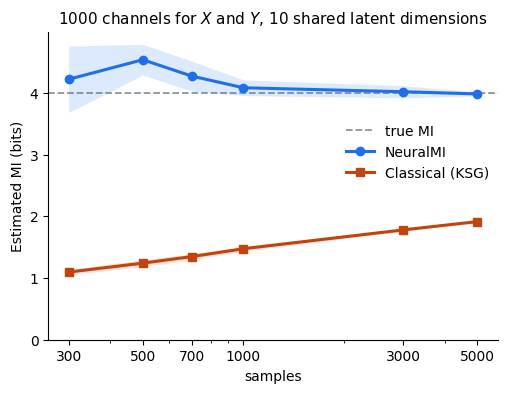

In [5]:
# The figure starts at 300 samples, where the smallest sweep point is off the scale.
n_list = np.array(nsweep['n_list'])[1:]
ksg3, neu3 = np.array(nsweep['ksg'])[1:], np.array(nsweep['neural'])[1:]

fig, ax = plt.subplots(figsize=(5.8, 4.0))
print(f"{'N':>6} {'KSG':>6} {'NeuralMI':>15}")
for N, k, m in zip(nsweep['n_list'], nsweep['ksg'], nsweep['neural']):
    print(f"{N:>6} {np.mean(k):>6.2f} {np.mean(m):>7.2f} +/- {np.std(m):.2f}")

ax.axhline(nsweep['mi_true'], ls='--', lw=1.3, color=GREY, zorder=1, label='true MI')

for vals, col, lab, mk in ((neu3, BLUE, 'NeuralMI', 'o'), (ksg3, RED, 'Classical (KSG)', 's')):
    m, sd = vals.mean(1), vals.std(1)
    ax.fill_between(n_list, m - sd, m + sd, color=col, alpha=.15, lw=0)
    ax.plot(n_list, m, mk + '-', color=col, lw=2.2, ms=6, label=lab, zorder=3)

ax.set_xscale('log')
ax.set_xticks(n_list); ax.set_xticklabels(n_list)
ax.set_xlabel('samples')
ax.set_ylabel('Estimated MI (bits)')
ax.set_title(r'$1000$ channels for $X$ and $Y$, $10$ shared latent dimensions')
ax.set_ylim(0, 4.99)
ax.legend(loc=(0.65, 0.5))

save(fig, 'sample_sweep')

## 3. Different modalities, different clocks

Spike times, a sampled trajectory and a blocky trial label, each on its own
clock and with gaps, become one aligned window grid. The right panel shows the
same content, cut into windows.

wrote ../source/_static/alignment.png


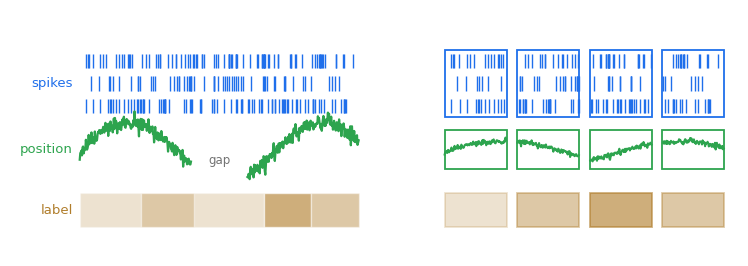

In [6]:
rng = np.random.default_rng(3)
T, NW = 10.0, 5
edges = np.linspace(0, T, NW + 1)

N_NEURONS = 3
spikes = [np.sort(rng.uniform(.2, T - .2, rng.integers(55, 95)))
          for _ in range(N_NEURONS)]

tt  = np.linspace(0, T, 500)
pos = 1.3 + .38 * np.sin(tt * .9) + .05 * rng.standard_normal(tt.size)
GAP_WINDOW = 2                                  # the window the gap falls in
pos[(tt >= edges[GAP_WINDOW]) & (tt < edges[GAP_WINDOW + 1])] = np.nan

lab_e = [0, 2.2, 4.1, 6.6, 8.3, T]
lab_v = [0, 1, 0, 2, 1]

# ---- one vertical layout shared by both panels, centred as a block --------
LAB_H, POS_H, SPK_ROW_H, ROW_GAP = .42, .5, .28, .3
block_h = LAB_H + ROW_GAP + POS_H + ROW_GAP + N_NEURONS * SPK_ROW_H
LAB_Y0 = 1.55 - block_h / 2
POS_Y0 = LAB_Y0 + LAB_H + ROW_GAP
SPK_Y0 = POS_Y0 + POS_H + ROW_GAP
spk_ys = SPK_Y0 + np.arange(N_NEURONS) * SPK_ROW_H

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 3.2),
                               gridspec_kw={'width_ratios': [1.15, 1]})

# left: as it arrives, each on its own clock
for y, s in zip(spk_ys, spikes):
    axL.vlines(s, y - .09, y + .09, color=BLUE, lw=1.0)
axL.plot(tt, pos, color=GREEN, lw=1.6)
for i in range(len(lab_e) - 1):
    axL.add_patch(Rectangle((lab_e[i], LAB_Y0), lab_e[i+1] - lab_e[i], LAB_H,
                            facecolor=AMBER, alpha=.22 + .2 * lab_v[i],
                            edgecolor='white', lw=1))
for y_, lab, col in ((spk_ys.mean(), 'spikes', BLUE),
                     (POS_Y0 + POS_H / 2, 'position', GREEN),
                     (LAB_Y0 + LAB_H / 2, 'label', AMBER)):
    axL.text(-.25, y_, lab, ha='right', va='center', fontsize=9.5, color=col)
axL.set_xlim(-2.5, T + .2); axL.set_ylim(0, 3.1)

# right: the same content, windowed. A window with a gap in any signal is
# dropped, since it would otherwise be drawn half-empty.
def window_complete(a, b):
    m = (tt >= a) & (tt < b)
    seg = pos[m]
    return seg.size > 0 and np.isfinite(seg).all()

valid_windows = [w for w in range(NW)
                 if window_complete(edges[w], edges[w + 1])]

for j, w in enumerate(valid_windows):
    a, b = edges[w], edges[w + 1]
    x0 = j * 2.05

    spk_box_y0 = spk_ys[0] - .14
    spk_box_h  = (spk_ys[-1] - spk_ys[0]) + .28
    axR.add_patch(Rectangle((x0, spk_box_y0), 1.75, spk_box_h, facecolor='none',
                            edgecolor=BLUE, lw=1.3))
    for y, s in zip(spk_ys, spikes):
        s_in = s[(s >= a) & (s < b)]
        if len(s_in):
            axR.vlines(x0 + 1.75 * (s_in - a) / (b - a), y - .09, y + .09,
                       color=BLUE, lw=1.0)

    axR.add_patch(Rectangle((x0, POS_Y0), 1.75, POS_H, facecolor='none',
                            edgecolor=GREEN, lw=1.3))
    m = (tt >= a) & (tt < b)
    seg = pos[m]
    xs = x0 + 1.75 * (tt[m] - a) / (b - a)
    ys = POS_Y0 + .1 + (POS_H - .2) * (seg - np.nanmin(pos)) / (np.nanmax(pos) - np.nanmin(pos))
    axR.plot(xs, ys, color=GREEN, lw=1.5)

    v = lab_v[min(w, len(lab_v) - 1)]
    axR.add_patch(Rectangle((x0, LAB_Y0), 1.75, LAB_H, facecolor=AMBER,
                            alpha=.22 + .2 * v, edgecolor=AMBER, lw=1.3))
axR.set_xlim(-.4, len(valid_windows) * 2.05 + .1); axR.set_ylim(0, 3.1)

axL.text(5.0, 1.13, 'gap', ha='center', va='bottom', fontsize=8.5, color='0.45')

for a_ in (axL, axR):
    a_.set_xticks([]); a_.set_yticks([])
    for s in a_.spines.values():
        s.set_visible(False)

save(fig, 'alignment')

## 4. One estimator, twelve questions

Every quantity in the library is $I(A; B \mid C)$ with a different choice of
which time offsets go into $A$, $B$ and $C$. The offsets follow the table in
`reference/THEORY.md`, drawn with short windows ($k = 3$, $L = 2$, $h = 2$ and a
block of 3) so the figure stays legible.


wrote ../source/_static/taxonomy.png


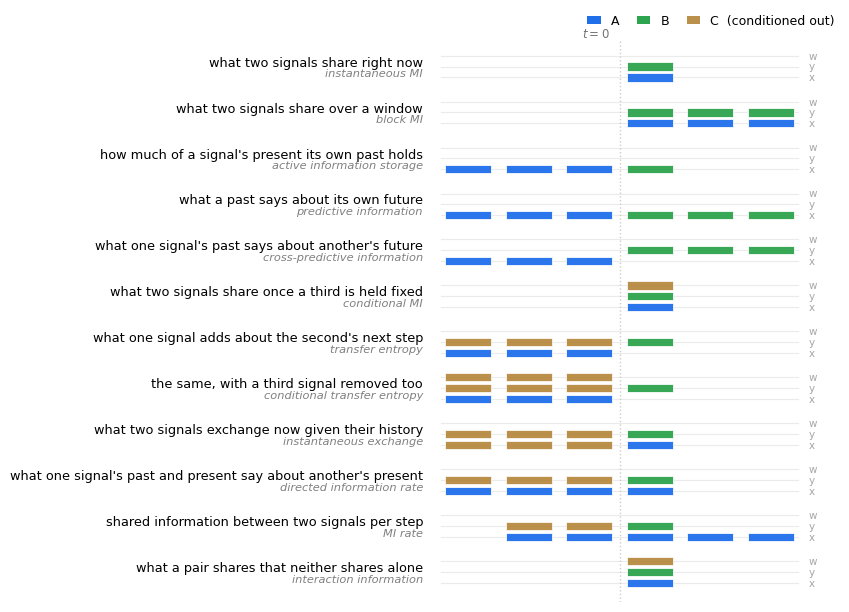

In [7]:
K, L, H, WB = 3, 2, 2, 3        # history k, MI-rate half-width L, MI-rate history h, block width
xs = lambda lo, hi: [('x', t) for t in range(lo, hi + 1)]
ys = lambda lo, hi: [('y', t) for t in range(lo, hi + 1)]
ws = lambda lo, hi: [('w', t) for t in range(lo, hi + 1)]

QUANTITIES = [
    ('what two signals share right now',        'instantaneous MI',
     xs(0, 0), ys(0, 0), []),
    ('what two signals share over a window',  'block MI',
     xs(0, WB - 1), ys(0, WB - 1), []),
    ("how much of a signal's present its own past holds", 'active information storage',
     xs(-K, -1), xs(0, 0), []),
    ('what a past says about its own future',   'predictive information',
     xs(-K, -1), xs(0, K - 1), []),
    ("what one signal's past says about another's future", 'cross-predictive information',
     xs(-K, -1), ys(0, K - 1), []),
    ('what two signals share once a third is held fixed', 'conditional MI',
     xs(0, 0), ys(0, 0), ws(0, 0)),
    ("what one signal adds about the second's next step",          'transfer entropy',
     xs(-K, -1), ys(0, 0), ys(-K, -1)),
    ('the same, with a third signal removed too','conditional transfer entropy',
     xs(-K, -1), ys(0, 0), ys(-K, -1) + ws(-K, -1)),
    ('what two signals exchange now given their history',   'instantaneous exchange',
     xs(0, 0), ys(0, 0), xs(-K, -1) + ys(-K, -1)),
    ("what one signal's past and present say about another's present",             'directed information rate',
     xs(-K, 0), ys(0, 0), ys(-K, -1)),
    ("shared information between two signals per step",             'MI rate',
     xs(-L, L), ys(0, 0), ys(-H, -1)),
    ('what a pair shares that neither shares alone', 'interaction information',
     xs(0, 0), ys(0, 0), ws(0, 0)),
]

LANES = {'x': 0, 'y': 1, 'w': 2}
LANE_H, ROW_H = .17, .72
T0, T1 = -K, K - 1

fig, ax = plt.subplots(figsize=(9.6, 7.7))
for i, (question, name, A, B, Cc) in enumerate(QUANTITIES):
    base = (len(QUANTITIES) - i - 1) * ROW_H
    for var, lane in LANES.items():
        ax.plot([T0 - .45, T1 + .45], [base + lane * LANE_H] * 2,
                color='0.92', lw=.8, zorder=0)
    for group, col, alpha in ((A, BLUE, .95), (B, GREEN, .95), (Cc, AMBER, .85)):
        for var, t in group:
            y0 = base + LANES[var] * LANE_H - LANE_H * .38
            ax.add_patch(Rectangle((t - .38, y0), .76, LANE_H * .76,
                                   facecolor=col, alpha=alpha,
                                   edgecolor='white', lw=.6, zorder=2))
    ax.text(T0 - .75, base + LANE_H * 1.4, question, ha='right', va='center', fontsize=9.3)
    ax.text(T0 - .75, base + LANE_H * .35, name, ha='right', va='center',
            fontsize=8.2, color='0.5', style='italic')
    for var, lane in LANES.items():
        ax.text(T1 + .62, base + lane * LANE_H, var, ha='left', va='center',
                fontsize=7.5, color='0.65')

ax.axvline(-.5, ymax=0.95, color='0.8', lw=1, ls=':', zorder=1)
top = len(QUANTITIES) * ROW_H
ax.text(-0.9, top - .13, r'$t = 0$', ha='center', va='bottom', fontsize=8.5, color='0.45')
ax.set_xlim(T0 - 6.2, T1 + 1.1)
ax.set_ylim(-.3, top + .35)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

leg = [Rectangle((0, 0), 1, 1, facecolor=BLUE), Rectangle((0, 0), 1, 1, facecolor=GREEN),
       Rectangle((0, 0), 1, 1, facecolor=AMBER, alpha=.85)]
ax.legend(leg, ['A', 'B', 'C  (conditioned out)'], loc='lower center',
          bbox_to_anchor=(0.83, 0.95), ncol=3, fontsize=9,
          handlelength=1.1, columnspacing=1.4)

save(fig, 'taxonomy')

Interaction information is the exception. It combines three estimates by a
formula, $I([X,W];Y) - I(X;Y) - I(W;Y)$, so its row shows the variables it reads.
`reference/THEORY.md` has the derivation and the references.


## 5. The README quickstart

The quickstart in `README.md`, which the docs' getting-started page includes,
run exactly as written. The cell fails if its output differs from the one the
README prints.


In [8]:
import contextlib, io, re

readme = (ROOT / 'README.md').read_text()
section = readme.split('<!-- quickstart-start -->')[1].split('<!-- quickstart-end -->')[0]
quick_code, quick_shown = re.search(r'```python\n(.*?)```\s*```\n(.*?)```', section, re.S).groups()

buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    exec(quick_code, {})
printed = buffer.getvalue()
print(printed)
assert printed.strip() == quick_shown.strip(), f'README shows:\n{quick_shown}'
print('matches the output README.md shows')


Run d5b37b58-65ad-4a32-8203-2b148788df58_c0:   0%|          | 0/100 [00:00<?, ?it/s]

estimate : 2.077 bits
exact    : 2.000 bits

matches the output README.md shows


## 6. The estimator built from scratch

The code blocks of `reference/ANATOMY.md`, run in order as one script, so the
page cannot drift into code that fails.


In [9]:
anatomy = (ROOT / 'reference' / 'ANATOMY.md').read_text()
blocks = re.findall(r'```python\n(.*?)```', anatomy, re.S)
print(f'{len(blocks)} code blocks')
exec('\n'.join(blocks), {})


4 code blocks
Epoch 0, MI Estimate (nats): 0.039
Epoch 2, MI Estimate (nats): 0.111
Epoch 4, MI Estimate (nats): 0.181
Epoch 6, MI Estimate (nats): 0.252
Epoch 8, MI Estimate (nats): 0.322
